In [ ]:
!pip install torch
!pip install torchvision



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import kagglehub
import os
path = kagglehub.dataset_download("sujaradha/thermal-images-diseased-healthy-leaves-paddy")
path = path+"/thermal images UL"
print("Path to dataset files:", path)
os.listdir(path)

100%|██████████| 44.3M/44.3M [00:00<00:00, 77.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sujaradha/thermal-images-diseased-healthy-leaves-paddy/versions/2/thermal images UL


['leaf spot',
 'healthy',
 'hispa',
 'leaf folder',
 'Read Me - Oryza sativa - TImages.docx',
 'BLB',
 'Blast']

In [ ]:
# Define transformations (Resize, Normalize, Augment)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

def train_and_evaluate(model_name, train_loader, val_loader, test_loader, num_classes=6, num_epochs=20, learning_rate=0.0001):
    # Select device (GPU if available)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nUsing device: {device}\n")

    # Load the requested model
    model_dict = {
        "ResNet50": models.resnet50,
        "ResNet101": models.resnet101,
        "EfficientNetV2": models.efficientnet_v2_s,
        "ViT": models.vit_b_16,
        "GoogleNet": models.googlenet,
        "InceptionV3": models.inception_v3,
        "VGG16": models.vgg16,
        "AlexNet": models.alexnet
    }

    if model_name not in model_dict:
        raise ValueError(f"Model '{model_name}' not supported!")

    model = model_dict[model_name](pretrained=True)

    # Adjust the classifier for the number of classes
    if "resnet" in model_name.lower() or "googlenet" in model_name.lower():
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif "efficientnet" in model_name.lower():
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif "vit" in model_name.lower():
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    elif "inception" in model_name.lower():
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif "vgg" in model_name.lower() or "alexnet" in model_name.lower():
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

    # Move model to device
    model = model.to(device)

    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training and validation loop
    print(f"\nTraining {model_name} for {num_epochs} epochs...\n")
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            # Update tqdm progress bar
            progress_bar.set_postfix(loss=running_loss / len(train_loader), accuracy=100 * correct / total)

        print(f"Epoch {epoch+1}: Loss = {running_loss / len(train_loader):.4f}, Accuracy = {100 * correct / total:.2f}%")

    # Evaluation function
    def evaluate_model(loader, dataset_type="Validation"):
        model.eval()
        correct, total, y_true, y_pred, y_scores = 0, 0, [], [], []

        with torch.no_grad():
            for inputs, labels in tqdm(loader, desc=f"🔍 Evaluating {dataset_type} Set", leave=True):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                y_scores.extend(outputs.cpu().numpy()) # Capture output scores for PR curve

                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        accuracy = 100 * correct / total
        print(f"\n{dataset_type} Set Accuracy: {accuracy:.2f}%")
        print(classification_report(y_true, y_pred))
        print(confusion_matrix(y_true, y_pred))

        # 🔹 Precision-Recall Curve Plot
        y_true_one_hot = np.eye(num_classes)[y_true]  # Convert to one-hot encoding

        plt.figure(figsize=(10, 6))
        for class_idx in range(num_classes):
            precision, recall, _ = precision_recall_curve(y_true_one_hot[:, class_idx], np.array(y_scores)[:, class_idx])
            plt.plot(recall, precision, label=f'Class {class_idx}')

        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve for {dataset_type} Set')
        plt.legend()
        plt.grid()
        plt.show()

    # Evaluate on Validation Set
    evaluate_model(val_loader, "Validation")
    # Evaluate on Test Set
    evaluate_model(test_loader, "Test")

    return model


Using device: cuda


Training ResNet50 for 20 epochs...



Epoch 1/20: 100%|██████████| 12/12 [00:04<00:00,  2.59it/s, accuracy=46.2, loss=1.42]


Epoch 1: Loss = 1.4206, Accuracy = 46.19%


Epoch 2/20: 100%|██████████| 12/12 [00:04<00:00,  2.66it/s, accuracy=78.5, loss=0.673]


Epoch 2: Loss = 0.6728, Accuracy = 78.48%


...

Epoch 19: Loss = 0.0858, Accuracy = 97.38%


Epoch 20/20: 100%|██████████| 12/12 [00:04<00:00,  2.55it/s, accuracy=97.4, loss=0.0833]


Epoch 20: Loss = 0.0833, Accuracy = 97.38%


🔍 Evaluating Validation Set: 100%|██████████| 4/4 [00:00<00:00,  5.73it/s]



Validation Set Accuracy: 92.13%
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        48
           1       1.00      0.92      0.96        12
           2       0.70      1.00      0.82        14
           3       0.93      0.96      0.94        26
           4       1.00      1.00      1.00         9
           5       1.00      0.61      0.76        18

    accuracy                           0.92       127
   macro avg       0.93      0.91      0.91       127
weighted avg       0.94      0.92      0.92       127

[[47  0  0  1  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 14  0  0  0]
 [ 1  0  0 25  0  0]
 [ 0  0  0  0  9  0]
 [ 1  0  6  0  0 11]]


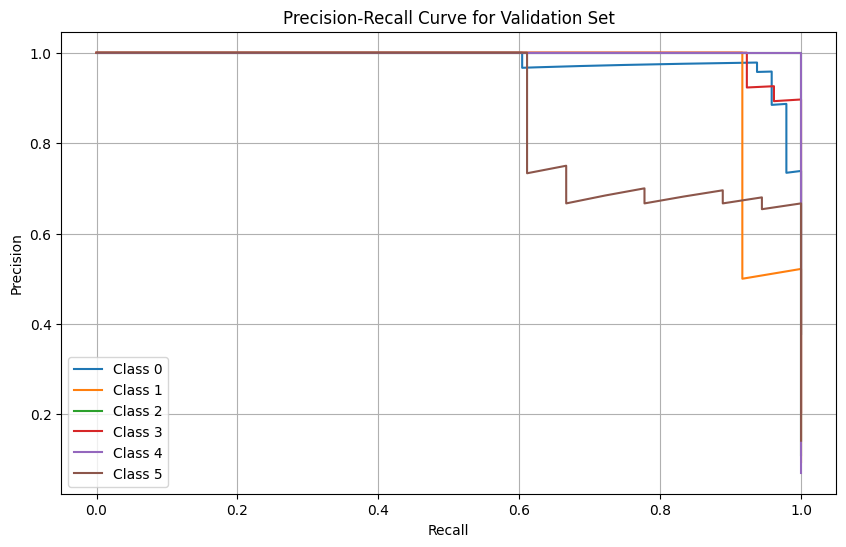

🔍 Evaluating Test Set: 100%|██████████| 4/4 [00:00<00:00,  5.62it/s]



Test Set Accuracy: 92.19%
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        44
           1       1.00      0.89      0.94        18
           2       0.77      1.00      0.87        17
           3       0.96      0.96      0.96        28
           4       1.00      1.00      1.00         2
           5       0.94      0.79      0.86        19

    accuracy                           0.92       128
   macro avg       0.93      0.93      0.93       128
weighted avg       0.93      0.92      0.92       128

[[41  0  2  0  0  1]
 [ 0 16  1  1  0  0]
 [ 0  0 17  0  0  0]
 [ 1  0  0 27  0  0]
 [ 0  0  0  0  2  0]
 [ 2  0  2  0  0 15]]


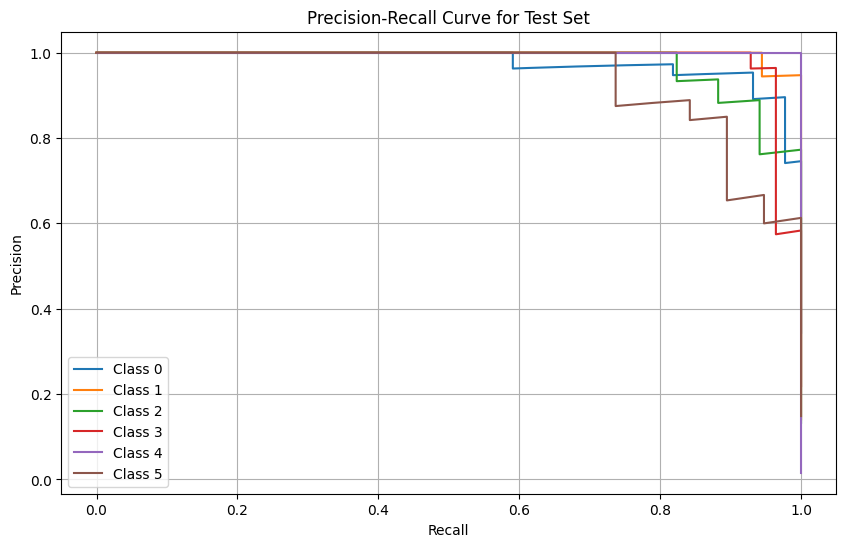

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
num_classes = 6
total_dataset_size = 636
batch_size = 32
img_height, img_width = 224, 224

# Assuming dataset is defined and loaded
thermal_images_path = path
dataset = datasets.ImageFolder(thermal_images_path, transform=transform)

# 🔹 Split dataset dynamically (60% Train, 20% Validation, 20% Test)
total_size = len(dataset)
train_size = int(0.6 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size  # Ensure this balances the split

# Now perform the split
train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

# Convert the dataset's targets to a tensor
dataset.targets = torch.tensor(dataset.targets)

# Adjust labels to be 0-indexed (if they are 1-indexed)
dataset.targets = dataset.targets - 1

# Now re-run the train/validation/test split
train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Call train_and_evaluate function
train_and_evaluate(
    model_name="ResNet50",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    num_epochs=20,
    learning_rate=0.0001
)



Using device: cuda



Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:01<00:00, 91.1MB/s]



Training ResNet101 for 20 epochs...



Epoch 1/20: 100%|██████████| 12/12 [00:07<00:00,  1.70it/s, accuracy=49.1, loss=1.39]


Epoch 1: Loss = 1.3917, Accuracy = 49.08%


...

Epoch 19: Loss = 0.0581, Accuracy = 97.64%


Epoch 20/20: 100%|██████████| 12/12 [00:07<00:00,  1.71it/s, accuracy=99.2, loss=0.0337]


Epoch 20: Loss = 0.0337, Accuracy = 99.21%


🔍 Evaluating Validation Set: 100%|██████████| 4/4 [00:01<00:00,  3.66it/s]



Validation Set Accuracy: 92.91%
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        48
           1       1.00      0.83      0.91        12
           2       0.78      1.00      0.88        14
           3       0.93      1.00      0.96        26
           4       1.00      1.00      1.00         9
           5       0.94      0.83      0.88        18

    accuracy                           0.93       127
   macro avg       0.93      0.93      0.93       127
weighted avg       0.94      0.93      0.93       127

[[44  0  3  0  0  1]
 [ 0 10  0  2  0  0]
 [ 0  0 14  0  0  0]
 [ 0  0  0 26  0  0]
 [ 0  0  0  0  9  0]
 [ 2  0  1  0  0 15]]


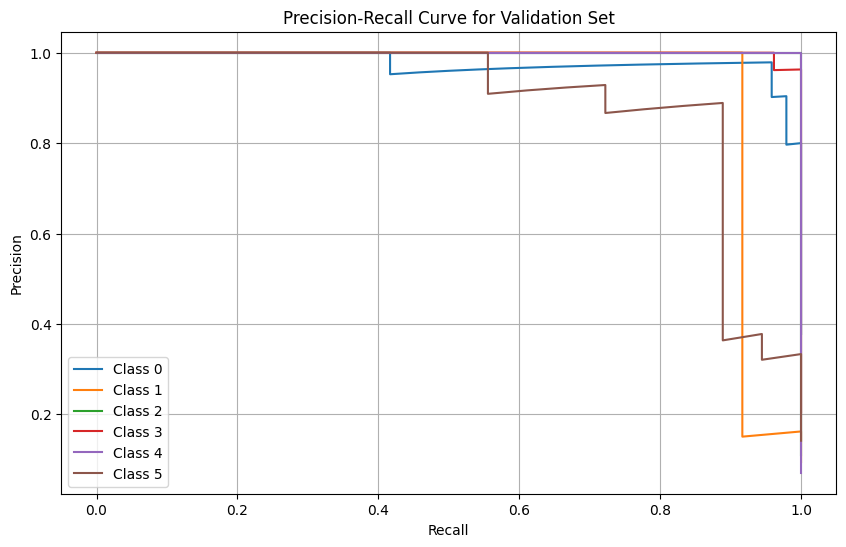

🔍 Evaluating Test Set: 100%|██████████| 4/4 [00:00<00:00,  4.26it/s]



Test Set Accuracy: 89.84%
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        44
           1       1.00      0.94      0.97        18
           2       0.74      1.00      0.85        17
           3       0.96      0.96      0.96        28
           4       0.50      1.00      0.67         2
           5       1.00      0.68      0.81        19

    accuracy                           0.90       128
   macro avg       0.85      0.91      0.86       128
weighted avg       0.92      0.90      0.90       128

[[39  0  3  0  2  0]
 [ 0 17  0  1  0  0]
 [ 0  0 17  0  0  0]
 [ 1  0  0 27  0  0]
 [ 0  0  0  0  2  0]
 [ 3  0  3  0  0 13]]


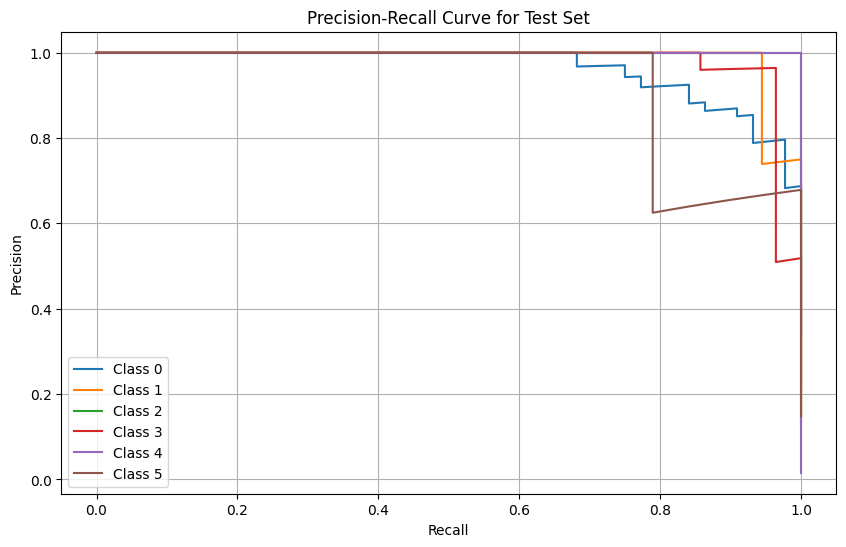

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:


# Call train_and_evaluate function
train_and_evaluate(
    model_name="ResNet101",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    num_epochs=20,
    learning_rate=0.0001
)



Using device: cuda



Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:00<00:00, 92.6MB/s]



Training EfficientNetV2 for 20 epochs...



Epoch 1/20: 100%|██████████| 12/12 [00:05<00:00,  2.27it/s, accuracy=35.2, loss=1.68]


Epoch 1: Loss = 1.6841, Accuracy = 35.17%


...

Epoch 19: Loss = 0.0199, Accuracy = 99.74%


Epoch 20/20: 100%|██████████| 12/12 [00:05<00:00,  2.35it/s, accuracy=99.2, loss=0.0289]


Epoch 20: Loss = 0.0289, Accuracy = 99.21%


🔍 Evaluating Validation Set: 100%|██████████| 4/4 [00:00<00:00,  5.57it/s]



Validation Set Accuracy: 93.70%
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        48
           1       1.00      0.92      0.96        12
           2       0.93      1.00      0.97        14
           3       0.90      1.00      0.95        26
           4       0.90      1.00      0.95         9
           5       1.00      0.83      0.91        18

    accuracy                           0.94       127
   macro avg       0.94      0.94      0.94       127
weighted avg       0.94      0.94      0.94       127

[[44  0  1  3  0  0]
 [ 1 11  0  0  0  0]
 [ 0  0 14  0  0  0]
 [ 0  0  0 26  0  0]
 [ 0  0  0  0  9  0]
 [ 2  0  0  0  1 15]]


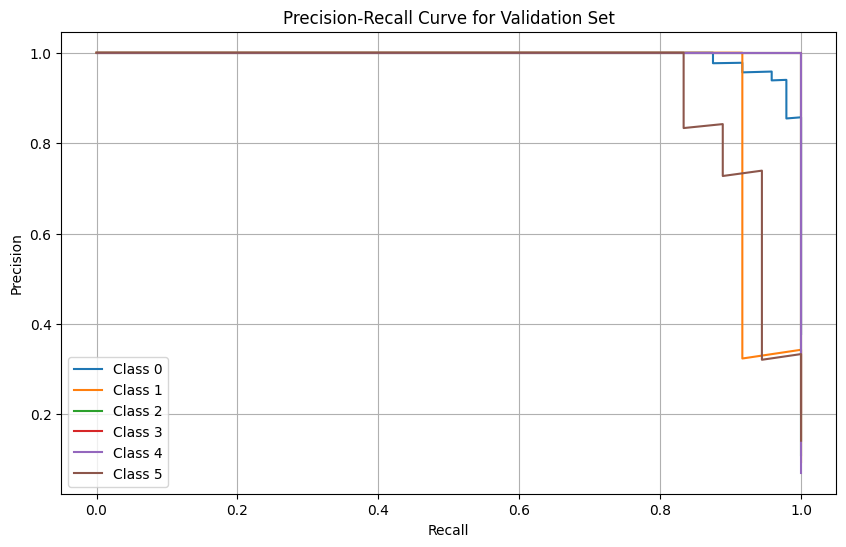

🔍 Evaluating Test Set: 100%|██████████| 4/4 [00:00<00:00,  5.42it/s]



Test Set Accuracy: 94.53%
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        44
           1       0.94      0.94      0.94        18
           2       0.94      0.94      0.94        17
           3       0.97      1.00      0.98        28
           4       0.50      1.00      0.67         2
           5       1.00      0.95      0.97        19

    accuracy                           0.95       128
   macro avg       0.88      0.96      0.91       128
weighted avg       0.95      0.95      0.95       128

[[40  1  1  0  2  0]
 [ 0 17  0  1  0  0]
 [ 1  0 16  0  0  0]
 [ 0  0  0 28  0  0]
 [ 0  0  0  0  2  0]
 [ 1  0  0  0  0 18]]


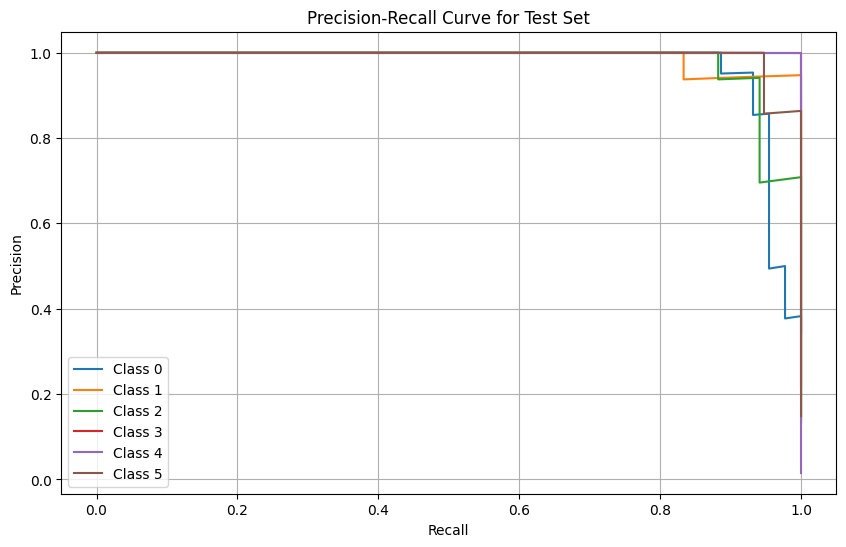

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [ ]:
# Call train_and_evaluate function
train_and_evaluate(
    model_name="EfficientNetV2",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    num_epochs=20,
    learning_rate=0.0001
)



Using device: cuda



Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:03<00:00, 91.6MB/s]



Training ViT for 20 epochs...



Epoch 1/20: 100%|██████████| 12/12 [00:13<00:00,  1.14s/it, accuracy=34.1, loss=1.67]


Epoch 1: Loss = 1.6684, Accuracy = 34.12%


...

Epoch 19: Loss = 0.0622, Accuracy = 97.64%


Epoch 20/20: 100%|██████████| 12/12 [00:13<00:00,  1.13s/it, accuracy=99.7, loss=0.0154]


Epoch 20: Loss = 0.0154, Accuracy = 99.74%


🔍 Evaluating Validation Set: 100%|██████████| 4/4 [00:01<00:00,  2.49it/s]


Validation Set Accuracy: 91.34%
              precision    recall  f1-score   support

           0       0.87      0.98      0.92        48
           1       1.00      0.92      0.96        12
           2       1.00      0.93      0.96        14
           3       0.93      0.96      0.94        26
           4       1.00      1.00      1.00         9
           5       0.85      0.61      0.71        18

    accuracy                           0.91       127
   macro avg       0.94      0.90      0.92       127
weighted avg       0.91      0.91      0.91       127

[[47  0  0  0  0  1]
 [ 0 11  0  1  0  0]
 [ 0  0 13  0  0  1]
 [ 1  0  0 25  0  0]
 [ 0  0  0  0  9  0]
 [ 6  0  0  1  0 11]]


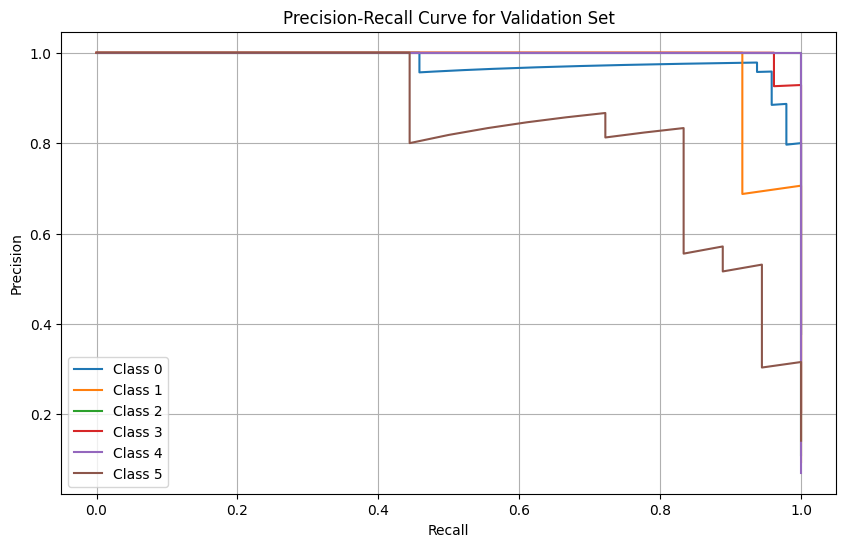

🔍 Evaluating Test Set: 100%|██████████| 4/4 [00:01<00:00,  2.51it/s]


Test Set Accuracy: 92.97%
              precision    recall  f1-score   support

           0       0.89      0.95      0.92        44
           1       1.00      1.00      1.00        18
           2       1.00      0.82      0.90        17
           3       0.93      0.96      0.95        28
           4       1.00      1.00      1.00         2
           5       0.89      0.84      0.86        19

    accuracy                           0.93       128
   macro avg       0.95      0.93      0.94       128
weighted avg       0.93      0.93      0.93       128

[[42  0  0  2  0  0]
 [ 0 18  0  0  0  0]
 [ 1  0 14  0  0  2]
 [ 1  0  0 27  0  0]
 [ 0  0  0  0  2  0]
 [ 3  0  0  0  0 16]]


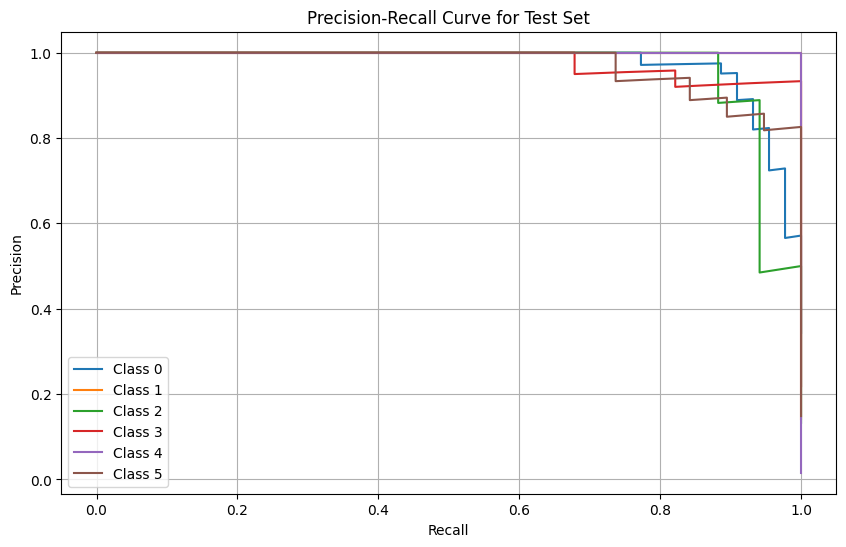

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
# Call train_and_evaluate function
train_and_evaluate(
    model_name="ViT",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    num_epochs=20,
    learning_rate=0.0001
)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth



Using device: cuda



100%|██████████| 49.7M/49.7M [00:00<00:00, 126MB/s]



Training GoogleNet for 20 epochs...



Epoch 1/20: 100%|██████████| 12/12 [00:02<00:00,  4.01it/s, accuracy=34.4, loss=1.66]


...

Epoch 19: Loss = 0.0873, Accuracy = 98.95%


Epoch 20/20: 100%|██████████| 12/12 [00:02<00:00,  4.72it/s, accuracy=99.7, loss=0.0421]


Epoch 20: Loss = 0.0421, Accuracy = 99.74%


🔍 Evaluating Validation Set: 100%|██████████| 4/4 [00:00<00:00,  5.79it/s]



Validation Set Accuracy: 95.28%
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        48
           1       1.00      0.83      0.91        12
           2       1.00      1.00      1.00        14
           3       0.93      0.96      0.94        26
           4       1.00      1.00      1.00         9
           5       1.00      0.83      0.91        18

    accuracy                           0.95       127
   macro avg       0.97      0.94      0.95       127
weighted avg       0.96      0.95      0.95       127

[[48  0  0  0  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 14  0  0  0]
 [ 1  0  0 25  0  0]
 [ 0  0  0  0  9  0]
 [ 3  0  0  0  0 15]]


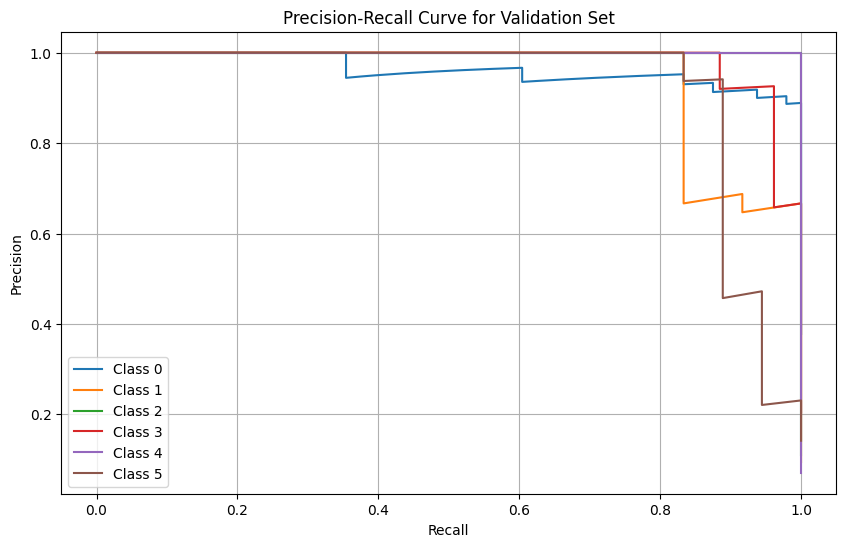

🔍 Evaluating Test Set: 100%|██████████| 4/4 [00:00<00:00,  5.99it/s]



Test Set Accuracy: 92.97%
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        44
           1       1.00      1.00      1.00        18
           2       0.93      0.82      0.88        17
           3       0.93      0.96      0.95        28
           4       0.67      1.00      0.80         2
           5       0.94      0.89      0.92        19

    accuracy                           0.93       128
   macro avg       0.90      0.94      0.91       128
weighted avg       0.93      0.93      0.93       128

[[41  0  0  2  1  0]
 [ 0 18  0  0  0  0]
 [ 2  0 14  0  0  1]
 [ 1  0  0 27  0  0]
 [ 0  0  0  0  2  0]
 [ 1  0  1  0  0 17]]


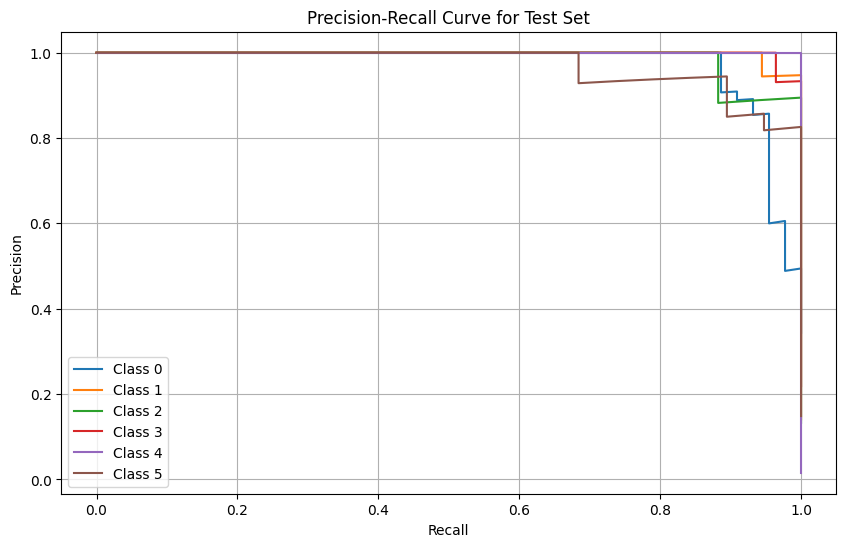

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [ ]:
# Call train_and_evaluate function
train_and_evaluate(
    model_name="GoogleNet",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    num_epochs=20,
    learning_rate=0.0001
)


Using device: cuda



Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:07<00:00, 76.2MB/s]



Training VGG16 for 20 epochs...



Epoch 1/20: 100%|██████████| 12/12 [00:06<00:00,  1.76it/s, accuracy=35.2, loss=1.61]


Epoch 1: Loss = 1.6099, Accuracy = 35.17%


...

Epoch 19: Loss = 0.1825, Accuracy = 93.96%


Epoch 20/20: 100%|██████████| 12/12 [00:06<00:00,  1.76it/s, accuracy=96.1, loss=0.124]


Epoch 20: Loss = 0.1243, Accuracy = 96.06%


🔍 Evaluating Validation Set: 100%|██████████| 4/4 [00:00<00:00,  4.20it/s]



Validation Set Accuracy: 86.61%
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        48
           1       0.79      0.92      0.85        12
           2       1.00      1.00      1.00        14
           3       0.86      0.96      0.91        26
           4       1.00      1.00      1.00         9
           5       1.00      0.50      0.67        18

    accuracy                           0.87       127
   macro avg       0.91      0.88      0.88       127
weighted avg       0.88      0.87      0.86       127

[[42  3  0  3  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 14  0  0  0]
 [ 1  0  0 25  0  0]
 [ 0  0  0  0  9  0]
 [ 9  0  0  0  0  9]]


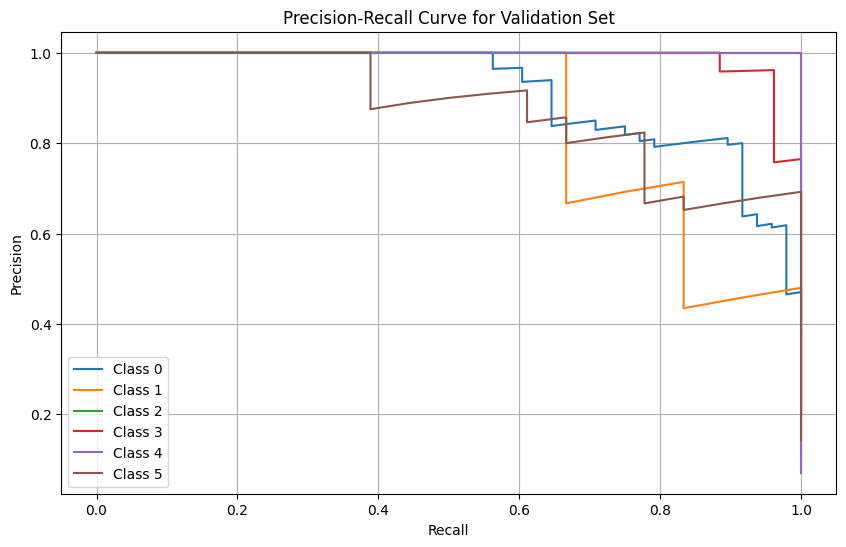

🔍 Evaluating Test Set: 100%|██████████| 4/4 [00:00<00:00,  4.22it/s]


Test Set Accuracy: 87.50%
              precision    recall  f1-score   support

           0       0.80      0.89      0.84        44
           1       0.90      1.00      0.95        18
           2       0.93      0.82      0.88        17
           3       0.96      0.96      0.96        28
           4       0.67      1.00      0.80         2
           5       0.92      0.63      0.75        19

    accuracy                           0.88       128
   macro avg       0.86      0.88      0.86       128
weighted avg       0.88      0.88      0.87       128

[[39  2  0  1  1  1]
 [ 0 18  0  0  0  0]
 [ 3  0 14  0  0  0]
 [ 1  0  0 27  0  0]
 [ 0  0  0  0  2  0]
 [ 6  0  1  0  0 12]]


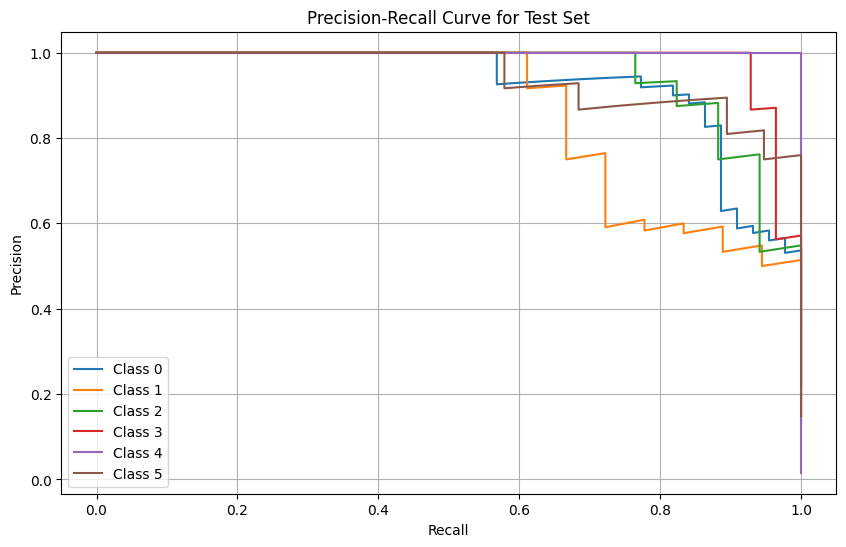

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# Call train_and_evaluate function
train_and_evaluate(
    model_name="VGG16",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    num_epochs=20,
    learning_rate=0.0001
)


Using device: cuda



Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:03<00:00, 65.0MB/s]



Training AlexNet for 20 epochs...



Epoch 1/20: 100%|██████████| 12/12 [00:01<00:00,  6.82it/s, accuracy=41.7, loss=1.49]


Epoch 1: Loss = 1.4945, Accuracy = 41.73%


...

Epoch 19: Loss = 0.0875, Accuracy = 97.38%


Epoch 20/20: 100%|██████████| 12/12 [00:01<00:00,  7.37it/s, accuracy=97.9, loss=0.0586]


Epoch 20: Loss = 0.0586, Accuracy = 97.90%


🔍 Evaluating Validation Set: 100%|██████████| 4/4 [00:00<00:00,  9.62it/s]



Validation Set Accuracy: 88.98%
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        48
           1       0.91      0.83      0.87        12
           2       1.00      1.00      1.00        14
           3       0.78      0.96      0.86        26
           4       1.00      1.00      1.00         9
           5       1.00      0.67      0.80        18

    accuracy                           0.89       127
   macro avg       0.93      0.89      0.90       127
weighted avg       0.90      0.89      0.89       127

[[43  1  0  4  0  0]
 [ 0 10  0  2  0  0]
 [ 0  0 14  0  0  0]
 [ 1  0  0 25  0  0]
 [ 0  0  0  0  9  0]
 [ 5  0  0  1  0 12]]


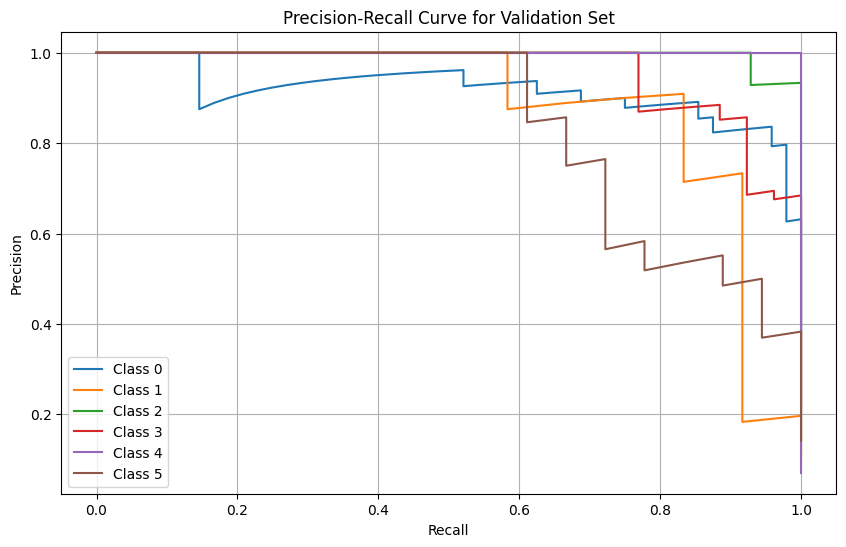

🔍 Evaluating Test Set: 100%|██████████| 4/4 [00:00<00:00,  9.65it/s]



Test Set Accuracy: 88.28%
              precision    recall  f1-score   support

           0       0.87      0.89      0.88        44
           1       0.85      0.94      0.89        18
           2       0.81      0.76      0.79        17
           3       0.96      0.96      0.96        28
           4       0.67      1.00      0.80         2
           5       0.94      0.79      0.86        19

    accuracy                           0.88       128
   macro avg       0.85      0.89      0.86       128
weighted avg       0.89      0.88      0.88       128

[[39  2  1  0  1  1]
 [ 0 17  0  1  0  0]
 [ 3  1 13  0  0  0]
 [ 1  0  0 27  0  0]
 [ 0  0  0  0  2  0]
 [ 2  0  2  0  0 15]]


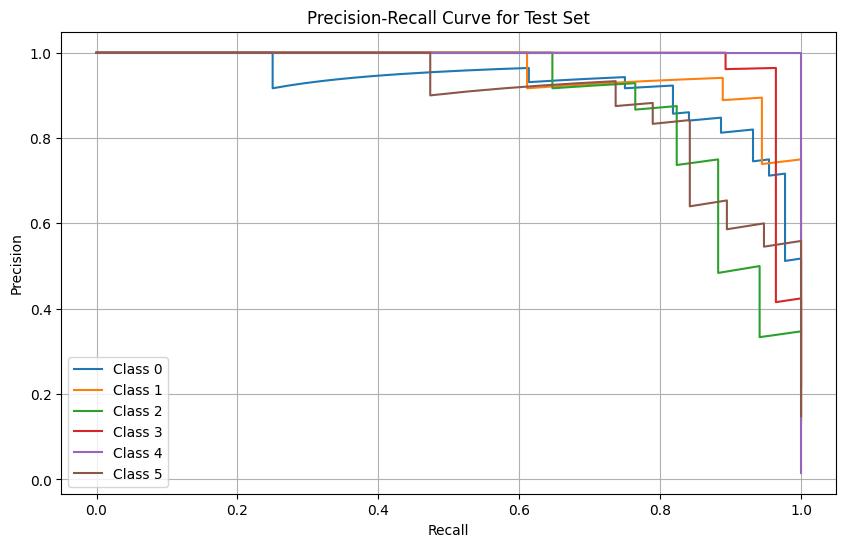

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
# Call train_and_evaluate function
train_and_evaluate(
    model_name="AlexNet",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    num_epochs=20,
    learning_rate=0.0001
)